# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

import joblib

# **2. Memuat Dataset dari Hasil Clustering**
Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [2]:
# Gunakan dataset hasil clustering yang memiliki fitur Target
# Silakan gunakan dataset data_clustering jika tidak menerapkan Interpretasi Hasil Clustering [Advanced]
# Silakan gunakan dataset data_clustering_inverse jika menerapkan Interpretasi Hasil Clustering [Advanced]
# Lengkapi kode berikut
df = pd.read_csv("/content/data_clustering_inverse.csv")

In [3]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionType,Location,Channel,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_binned,CustomerAge_binned,Target
0,1,36,0,0,81.0,1.0,5112.21,589.828639,116.013717,2
1,1,15,0,0,141.0,1.0,13758.91,297.656468,116.013717,1
2,1,23,2,3,56.0,1.0,1122.35,882.000811,44.678444,1
3,1,33,2,3,25.0,1.0,8569.06,882.000811,44.678444,2
4,1,28,0,3,172.0,1.0,781.68,589.828639,44.678444,1


# **3. Data Splitting**
Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [4]:
# Menggunakan train_test_split() untuk melakukan pembagian dataset.
X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **4. Membangun Model Klasifikasi**
Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Menggunakan algoritma klasifikasi yaitu Decision Tree.
2. Latih model menggunakan data yang sudah dipisah.

In [5]:
# Buatlah model klasifikasi menggunakan Decision Tree
model_dt = DecisionTreeClassifier(random_state=42)

# Latih model pada data train
model_dt.fit(X_train, y_train)

# Prediksi data test
y_pred_dt = model_dt.predict(X_test)

# Evaluasi model Decision Tree
print("Evaluasi Model: Decision Tree")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_dt, average='weighted'))
print("F1-Score :", f1_score(y_test, y_pred_dt, average='weighted'))

Evaluasi Model: Decision Tree
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


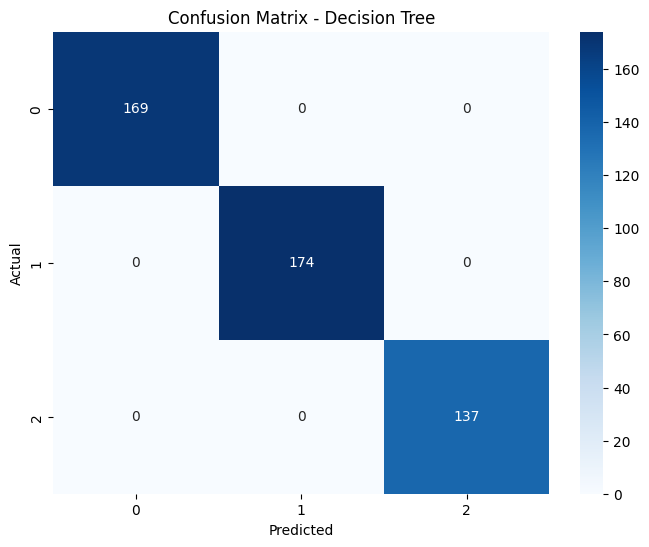

In [6]:
# Menampilkan confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [7]:
# Menyimpan Model
joblib.dump(model_dt, 'decision_tree_model.h5')

['decision_tree_model.h5']

# **5. Memenuhi Kriteria Skilled dan Advanced dalam Membangun Model Klasifikasi**



**Biarkan kosong jika tidak menerapkan kriteria skilled atau advanced**

In [8]:
# Melatih model menggunakan algoritma klasifikasi scikit-learn selain Decision Tree.
# Random Forest
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

In [9]:
print("Evaluasi Model: Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1-Score :", f1_score(y_test, y_pred_rf, average='weighted'))

Evaluasi Model: Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


In [10]:
# Menyimpan Model Selain Decision Tree
joblib.dump(model_rf, 'explore_rf_classification.h5')

['explore_rf_classification.h5']

Hyperparameter Tuning Model

Pilih salah satu algoritma yang ingin Anda tuning

In [11]:
# Lakukan Hyperparameter Tuning dan Latih ulang.
# Lakukan dalam satu cell ini saja.
param_grid_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_search_rf = RandomizedSearchCV(estimator=model_rf, param_distributions=param_grid_rf,
                                      n_iter=10, cv=5, random_state=42, n_jobs=-1)

random_search_rf.fit(X_train, y_train)

best_params_rf = random_search_rf.best_params_
model_rf_tuned = random_search_rf.best_estimator_

print("Best Hyperparameters for Random Forest:", best_params_rf)

y_pred_rf_tuned = model_rf_tuned.predict(X_test)

Best Hyperparameters for Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}


In [12]:
# Menampilkan hasil evaluasi akurasi, presisi, recall, dan F1-Score pada algoritma yang sudah dituning.
print("Evaluasi Model: Tuned Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_rf_tuned, average='weighted'))
print("F1-Score :", f1_score(y_test, y_pred_rf_tuned, average='weighted'))

Evaluasi Model: Tuned Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


In [13]:
# Menyimpan Model hasil tuning
joblib.dump(model_rf_tuned, 'tuning_classification.h5')

['tuning_classification.h5']

End of Code